# ANÁLISIS EXLPORATORIO DE DATOS

A continuacion se presenta el análisis exploratorio de los datos obtenidos para el desarrollo de un Sistema Clasificador de Resultados de Análisis de Aceite Usado en Motores de Maquinaria Pesada.

Los datos aportados corresponden a los resultados de los análisis de aceite usado de motores de maquinaria pesada en los ultimos 2 años de la organización. A modo de introducción general a este conjunto de datos se puede decir que contienen la información de identificación del equipo del cual la muestra fue tomada, la fecha de toma de la muestra de aceite, los resultados obtenidos por diferentes técnicas de laboratorio de lubricantes como son: resultados de espectrometría, infrarojos y pruebas especificas como la viscosidad a 100°C y el porcentaje de combustible diluido en el aceite; adicionalmente se incluye la calificación realizada por los analisisas de confiabilidad sobre dichos resultados indicando la severidad (Normal, Advertencia o Critico) y el modo de falla (Alta tasa de desgaste metalico, entrada de tierra, entrada de combustible, entre otros).

Esta información fue suministrada en un solo archivo de excel y proviene de la base de datos de análisis del cliente.

A continucación se realiza una lectura preliminar de los datos y se muestran los primeros 5 registros para inspeccionar el contenido y estructura de los datos.

In [11]:
# Abrir csv usando la ruta definida
import pandas as pd
data = pd.read_csv(r"../Data/Data_Anonimizada.csv")
data.head()

,Component ID,Asset ID,Flota,Location,Component Profile,Lubricant,Connection Code,Observation Type,Observation Date,Observation Code,...,Plomo (ppm),Color del Refrigerante,Glycerin (%),Nitrito (ppm),PUNTO DE EBULLICION (°C),Sólidos Totales Disueltos (ppm),Turbidez (NTU),pH,Titanio (ppm),Vanadio (ppm)
0,Component_ID_54,Asset_ID_42,Flota_3,Location_1,Component_Profile_4,Lubricant_1,Connection_Code_63,Fluid Analysis,2025-01-26,Observation_Code_4112,...,0.42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Component_ID_42,Asset_ID_30,Flota_2,Location_1,Component_Profile_1,Lubricant_1,Connection_Code_46,Fluid Analysis,2025-01-26,Observation_Code_3219,...,0.09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Component_ID_28,Asset_ID_16,Flota_2,Location_1,Component_Profile_1,Lubricant_1,Connection_Code_32,Fluid Analysis,2025-01-25,Observation_Code_2161,...,0.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Component_ID_19,Asset_ID_10,Flota_1,Location_1,Component_Profile_2,Lubricant_1,Connection_Code_24,Fluid Analysis,2025-01-25,Observation_Code_1738,...,0.91,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Component_ID_20,Asset_ID_10,Flota_1,Location_1,Component_Profile_2,Lubricant_1,Connection_Code_23,Fluid Analysis,2025-01-25,Observation_Code_1732,...,1.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Parte I: Calidad de datos

De acuerdo a lo informado por el cliente las primeras columnas del conjunto de datos fueron anonimizadas para salvaguardar la identidad de la organización y sus activos. Adicionalmente se informa que la base de datos al contener resultados para diversos tipos de componentes contiene columnas que no se usan en los analisis de muestras de aceite de motor, tal es el caso de columnas de resultados relacionados con pruebas de refrigerante y las relacionadas con pruebas de limpieza ISO 4406 usadas para aceites hidraulicos.

### **Descripción de las columnas**
A continuacion se describen todas las columnas del conjunto de datos:
* Component ID: Identificación del componente
* Asset ID: Identificacion del activo (ID de la maquinaria)
* Flota: Grupo de activos al que pertenece la maquinaria
* Location: Grupo de activos en la base de datos de analisis de resultados de aceite usado
* Component Profile: Identificación del perfil de limites que usa la base datos para analisis basado en reglas
* Lubricant: Descripción del tipo de lubricante
* Connection Code: Llave primaria del registro en la base de datos de analisis
* Observation Type: Identificación del tipo de registro, para este caso todos son registros de analisis de fluidos
* Observation Date: Fecha de toma de la muestra de aceite
* Observation Code: ID del registro
* Meter Reading: Lectura del medidor de servicio del componente al momento de la toma de muestra
* All Time Meter Reading: Lectura del medidor de servicio de la maquinaria al momento de la toma de muestra
* Component Age: Horas de servicio del componente
* Observation Interval: Horas de servicio desde la ultima muestra de aceite para el mismo comoponente y maquinaria
* days: Dias desde la ultima muestra de aceite para el mismo comoponente y maquinaria
* Observation Rating: Clasificacion preliminar de severidad de la condición
* Rule Based Rating: Clasificación automatica realizada por el software de analisis
* Lube Age: Horas de servicio del lubricante
* Live: Vida del activo
* Lube Drained: Indica si el lubricante fue cambiado en la ultima intervención del equipo
* Added: Camtidad de aceite completado al componente
* Assigned Condition Rating: Severidad asignada por el analista
* Condition Review Notes: Notas de la revisión realizada por el analista
* Further Recommendations: Recomnendaciones adicionales dadas por el analista
* Fault Effect: Selección del modo de falla
* Reviewed: Fecha de revisión
* Reviewer: Persona que realizó la revisión
* Action Summary: Lista de acciones para el analista
* Boro (ppm): Contenido de boro en partes por millón (ppm)
* Calcio (ppm): Contenido de calcio en partes por millón (ppm)
* Cinc (ppm): Contenido de zinc en partes por millón (ppm)
* Fosforado (ppm): Contenido de fosforo en partes por millón (ppm)
* Magnesio (ppm): Contenido de magnesio en partes por millón (ppm)
* Molibdeno (ppm): Contenido de molibdeno en partes por millón (ppm)
* SILICATOS (ppm): Contenido de silicatos en partes por millón (ppm)
* Agua (%): Contenido de agua en porcentaje (%)
* Dilución por combustible (%): Contenido de combustible en porcentaje (%)
* Hollín JOAP (Abs/cm): Contenido de hollín en la muestra de aceite medido en absorbancia por centimetro (abs/cm)
* Nitración JOAP (Abs/cm): Contenido de nitración en la muestra de aceite medido en absorbancia por centimetro (abs/cm)
* Oxidación JOAP (Abs/cm): Contenido de oxidación en la muestra de aceite medido en absorbancia por centimetro (abs/cm)
* Silicio (ppm): Contenido de silicio en partes por millón (ppm)
* Sodio (ppm): Contenido de sodio en partes por millón (ppm)
* Sulfatación JOAP (Abs/cm): Contenido de sulfatación en la muestra de aceite medido en absorbancia por centimetro (abs/cm)
* Viscosidad @ 100°C (cSt): Viscosidad del aceite a 100°C
* ISO 4406:1999 > 04µ: Contenido de particulas mayores a 4 micras por cada mililitro de lubricante
* ISO 4406:1999 > 06µ: Contenido de particulas mayores a 6 micras por cada mililitro de lubricante
* ISO 4406:1999 > 14µ: Contenido de particulas mayores a 14 micras por cada mililitro de lubricante
* Aluminio (ppm): Contenido de aluminio en partes por millón (ppm)
* Bario (ppm): Contenido de bario en partes por millón (ppm)
* Cadmio (ppm): Contenido de cadmio en partes por millón (ppm)
* Cobre (ppm): Contenido de cobre en partes por millón (ppm)
* Cromo (ppm): Contenido de cromo en partes por millón (ppm)
* Estaño (ppm): Contenido de estaño en partes por millón (ppm)
* Hierro (ppm): Contenido de hierro en partes por millón (ppm)
* Niquel (ppm): Contenido de niquel en partes por millón (ppm)
* Partículas Ferrosas (ppm): Contenido de particulas ferrosas en partes por millón (ppm)
* Plomo (ppm): Contenido de plomo en partes por millón (ppm)
* Color del Refrigerante: Indicador del color del refrigerante (Para muestras de refrigerante)
* Glycerin (%): Porcentaje de glicerina en el refrigerante (Para muestras de refrigerante)
* Nitrito (ppm): Contenido de nitritos en partes por millón (ppm) (Para muestras de refrigerante)
* PUNTO DE EBULLICION (°C): Punto de ebullición del refrigerante (Para muestras de refrigerante)
* Sólidos Totales Disueltos (ppm): Contenido de solidos en suspensión en partes por millón (ppm) (Para muestras de refrigerante)
* Turbidez (NTU): Indicador de la turbidez del refrigerante (Para muestras de refrigerante)
* pH: Potencial de hidrogeno pH de la muestra de refrigerante (Para muestras de refrigerante)
* Titanio (ppm): Contenido de titanio en partes por millón (ppm)
* Vanadio (ppm): Contenido de vanadio en partes por millón (ppm)

### **¿Que significa o como puede entenderse cada fila del dataframe?**
Cada fila representa un resultado de analisis de aceite conteniendo la informacion de identificacion de la muestra y de los resultadois puntuales de diferentes pruebas de laboratorio alos que el lubricante usado es sometido para revelar sus propiedades y contenido de elementos de interes para estimar el estado de "salud" de la maquinaria en terminos de modos de falla potenciales y el grado de severidad.

### **¿Qué tamaño tiene el conjunto de datos?**

In [13]:
data.shape

(4297, 66)

En la muestra de datos compartida se teiene un total de 4297 registros y 66 columnas. Todos los registros corresponden a muestras de aceite de motores de maquinaria pesada.

### **¿Qué tipo de datos tienen las columnas?**

In [15]:
data.dtypes.value_counts()

float64    45
object     20
int64       1
Name: count, dtype: int64

Se tiene un total de 46 columnas numericas (45 de tipo flotante y 1 de tipo entero), las 20 restantes son columnas categoricas de tipo object. Esto permite conocer que el dataframe es mayoritariamente numérico.

### **¿Hay filas duplicadas?**

In [16]:
# Conteno de filas duplicadas
data.duplicated().sum()

np.int64(0)

No se encuentran duplicados a nivel de filas. Por lo que el conjunto de datos contiene registros unicos. Este es un punto importante en la revisión de calidad de los datos.

### **Análisis de Completitud de los datos**

In [19]:
# Generar una tabla con porcentaje de faltantes por columnas y otra columna de cardinalidad por columna
faltantes = pd.DataFrame({
    'Faltantes': data.isnull().mean() * 100,
}) 
faltantes.sort_values(by='Faltantes', ascending=False)


,Faltantes
Titanio (ppm),100.0
Niquel (ppm),100.0
Cadmio (ppm),100.0
ISO 4406:1999 > 04µ,100.0
Vanadio (ppm),100.0
...,...
Meter Reading,0.0
Component Age,0.0
All Time Meter Reading,0.0
Observation Rating,0.0


In [21]:
cardinalidad = pd.DataFrame({
    'cardinalidad': data.nunique()
})
cardinalidad.sort_values(by='cardinalidad', ascending=True)

,cardinalidad
Bario (ppm),0
ISO 4406:1999 > 06µ,0
Niquel (ppm),0
Cadmio (ppm),0
ISO 4406:1999 > 04µ,0
...,...
Meter Reading,3411
All Time Meter Reading,3678
Component Age,3949
Live,3949


Los anteriores resultados indican que se tiene un numero importante de columnas practicamente vacias, con un % de faltantes igual o cercano a 100%. Entre ellas se tienen:
* `Titanio (ppm)`
* `Niquel (ppm)`
* `Cadmio (ppm)`
* `ISO 4406:1999 > 04µ`
* `Bario (ppm)`
* `ISO 4406:1999 > 14µ`
* `SILICATOS (ppm)`
* `PUNTO DE EBULLICION (°C)`
* `Glycerin (%)`
* `Color del Refrigerante`
* `pH`
* `Turbidez (NTU)`
* `Nitrito (ppm)`
* `Sólidos Totales Disueltos (ppm)`
* `Lube Age`
* `Action Summary`

Por otra parte tambien se tienen columnas con una cardinalidad muy baja, algunas incluso con cardinalidad igual a 1 lo que las hace inutiles para la construccion de modelos predictibvos, tal es el caso de:
* `Added`
* `Color del Refrigerante`
* `Observation Type`
* `Lube Drained`
* `Location`
* `Lubricant`

Estas columnas al estar vacias o poseer una única categoria o valor deberan ser eliminadas del conjunto de datos.

<Axes: >

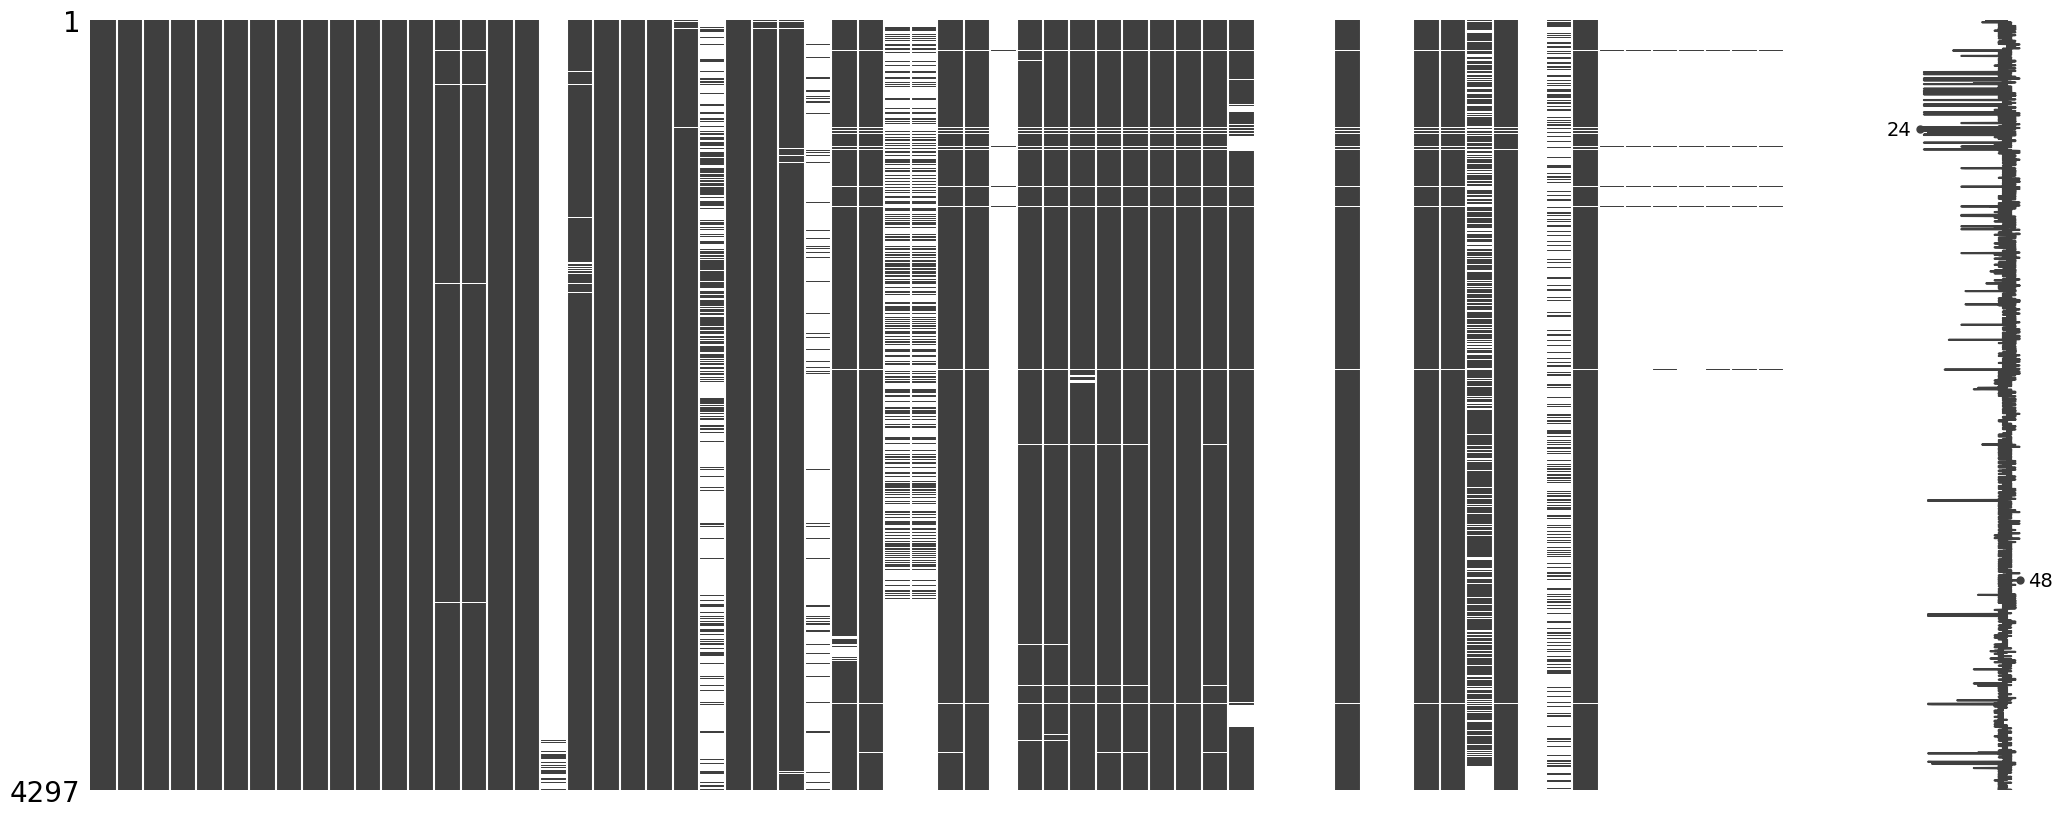

In [22]:
import missingno as msno
msno.matrix(data)

<Figure size 3200x2000 with 0 Axes>

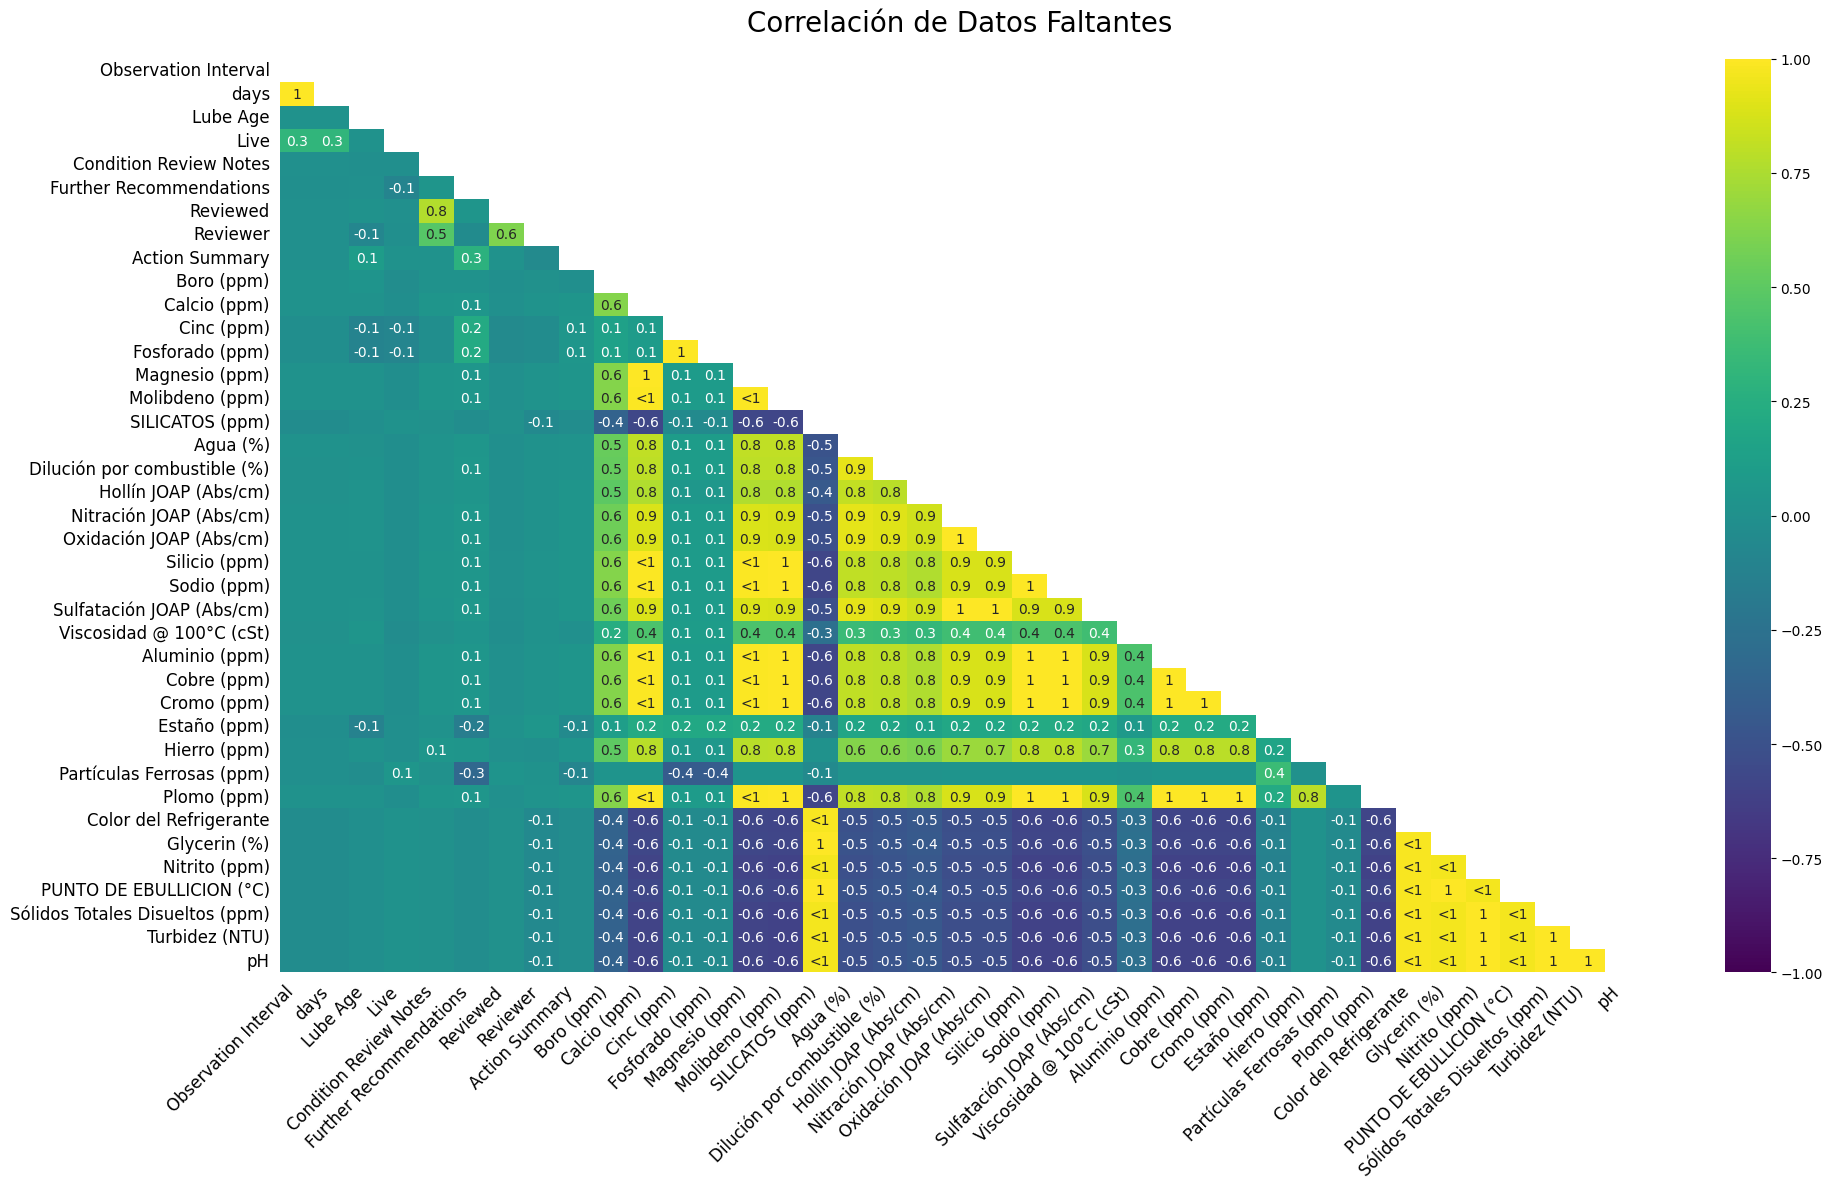

In [25]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16, 10), dpi=200)

ax = msno.heatmap(
    data,
    cmap="viridis",     # paleta profesional
    fontsize=12         # etiqueta de celdas más nítida
)

ax.set_title(
    "Correlación de Datos Faltantes",
    fontsize=20,
    pad=20
)

ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

* Hay bloques de columnas con correlaciones cercanas a 1.0, lo que indica que faltan juntas porque pertenecen al mismo proceso o análisis de laboratorio.
* El grupo de variables de metales y contaminantes (Calcio, Zinc, Magnesio, etc.) forma un bloque claro: si falta una, faltan todas.
* Las variables del paquete JOAP (Hollín, Nitración, Oxidación, Sulfatación) también muestran correlaciones casi perfectas entre sí.
* Existen correlaciones negativas entre algunos bloques, lo que indica que ciertos análisis rara vez faltan al mismo tiempo; provienen de procesos distintos.
* Algunas variables administrativas (como Observation Interval o days) muestran correlaciones bajas, indicando faltantes independientes.
* En resumen, los faltantes no son aleatorios: se agrupan por módulos de análisis, lo cual tiene impacto en la imputación, el modelado, y el diagnóstico.

## Parte II: Entendimiento de los datos

* Descripción de estadisticas basicas
* Análisis de distribucion de los datos
* Distribuciones frente a las categorias de la variable objetivo
* Feature importance
* Adición de nueva información

In [26]:
data.describe()

,Meter Reading,All Time Meter Reading,Component Age,Observation Interval,days,Lube Age,Live,Added,Boro (ppm),Calcio (ppm),...,Plomo (ppm),Color del Refrigerante,Glycerin (%),Nitrito (ppm),PUNTO DE EBULLICION (°C),Sólidos Totales Disueltos (ppm),Turbidez (NTU),pH,Titanio (ppm),Vanadio (ppm)
count,4297.000000,4297.00000,4297.000000,4273.000000,4273.000000,114.000000,4237.000000,4297.0,4112.000000,4219.000000,...,4221.000000,27.0,26.000000,28.000000,26.000000,28.000000,28.000000,28.000000,0.0,0.0
mean,37718.445041,40323.21411,8605.917747,246.894533,16.265621,7222.688421,8679.136592,0.0,58.141029,2149.858808,...,1.099069,0.0,48.443077,1751.428571,106.584615,914.571429,21.607143,9.453571,NaN,NaN
std,24265.299867,24727.10970,7865.818600,407.557769,15.205517,3579.832924,7848.997992,0.0,39.746011,865.738186,...,2.094020,0.0,1.214311,171.047195,0.242804,184.793865,3.993878,0.705262,NaN,NaN
min,0.000000,0.00000,0.000000,0.000000,1.000000,285.490000,0.000000,0.0,0.000000,1.660000,...,0.000000,0.0,45.700000,1400.000000,106.100000,605.000000,20.000000,8.200000,NaN,NaN
25%,15113.480000,17012.62000,3712.030000,100.030000,7.000000,4116.575000,3853.400000,0.0,35.210000,1607.000000,...,0.000000,0.0,47.637500,1630.000000,106.400000,790.250000,20.000000,8.875000,NaN,NaN
50%,39790.300000,42576.53000,7442.050000,195.100000,13.000000,7426.295000,7477.100000,0.0,60.260000,1804.000000,...,0.780000,0.0,48.775000,1750.000000,106.650000,897.000000,20.000000,9.650000,NaN,NaN
75%,59400.140000,61160.00000,11850.940000,316.130000,22.000000,10378.597500,11835.370000,0.0,87.397500,2393.000000,...,1.120000,0.0,49.315000,1880.000000,106.775000,992.000000,20.000000,10.100000,NaN,NaN
max,86467.570000,88527.24000,64709.850000,13231.070000,152.000000,16105.060000,64709.850000,0.0,395.440000,5411.000000,...,60.320000,0.0,50.180000,2000.000000,107.000000,1340.000000,33.000000,10.500000,NaN,NaN


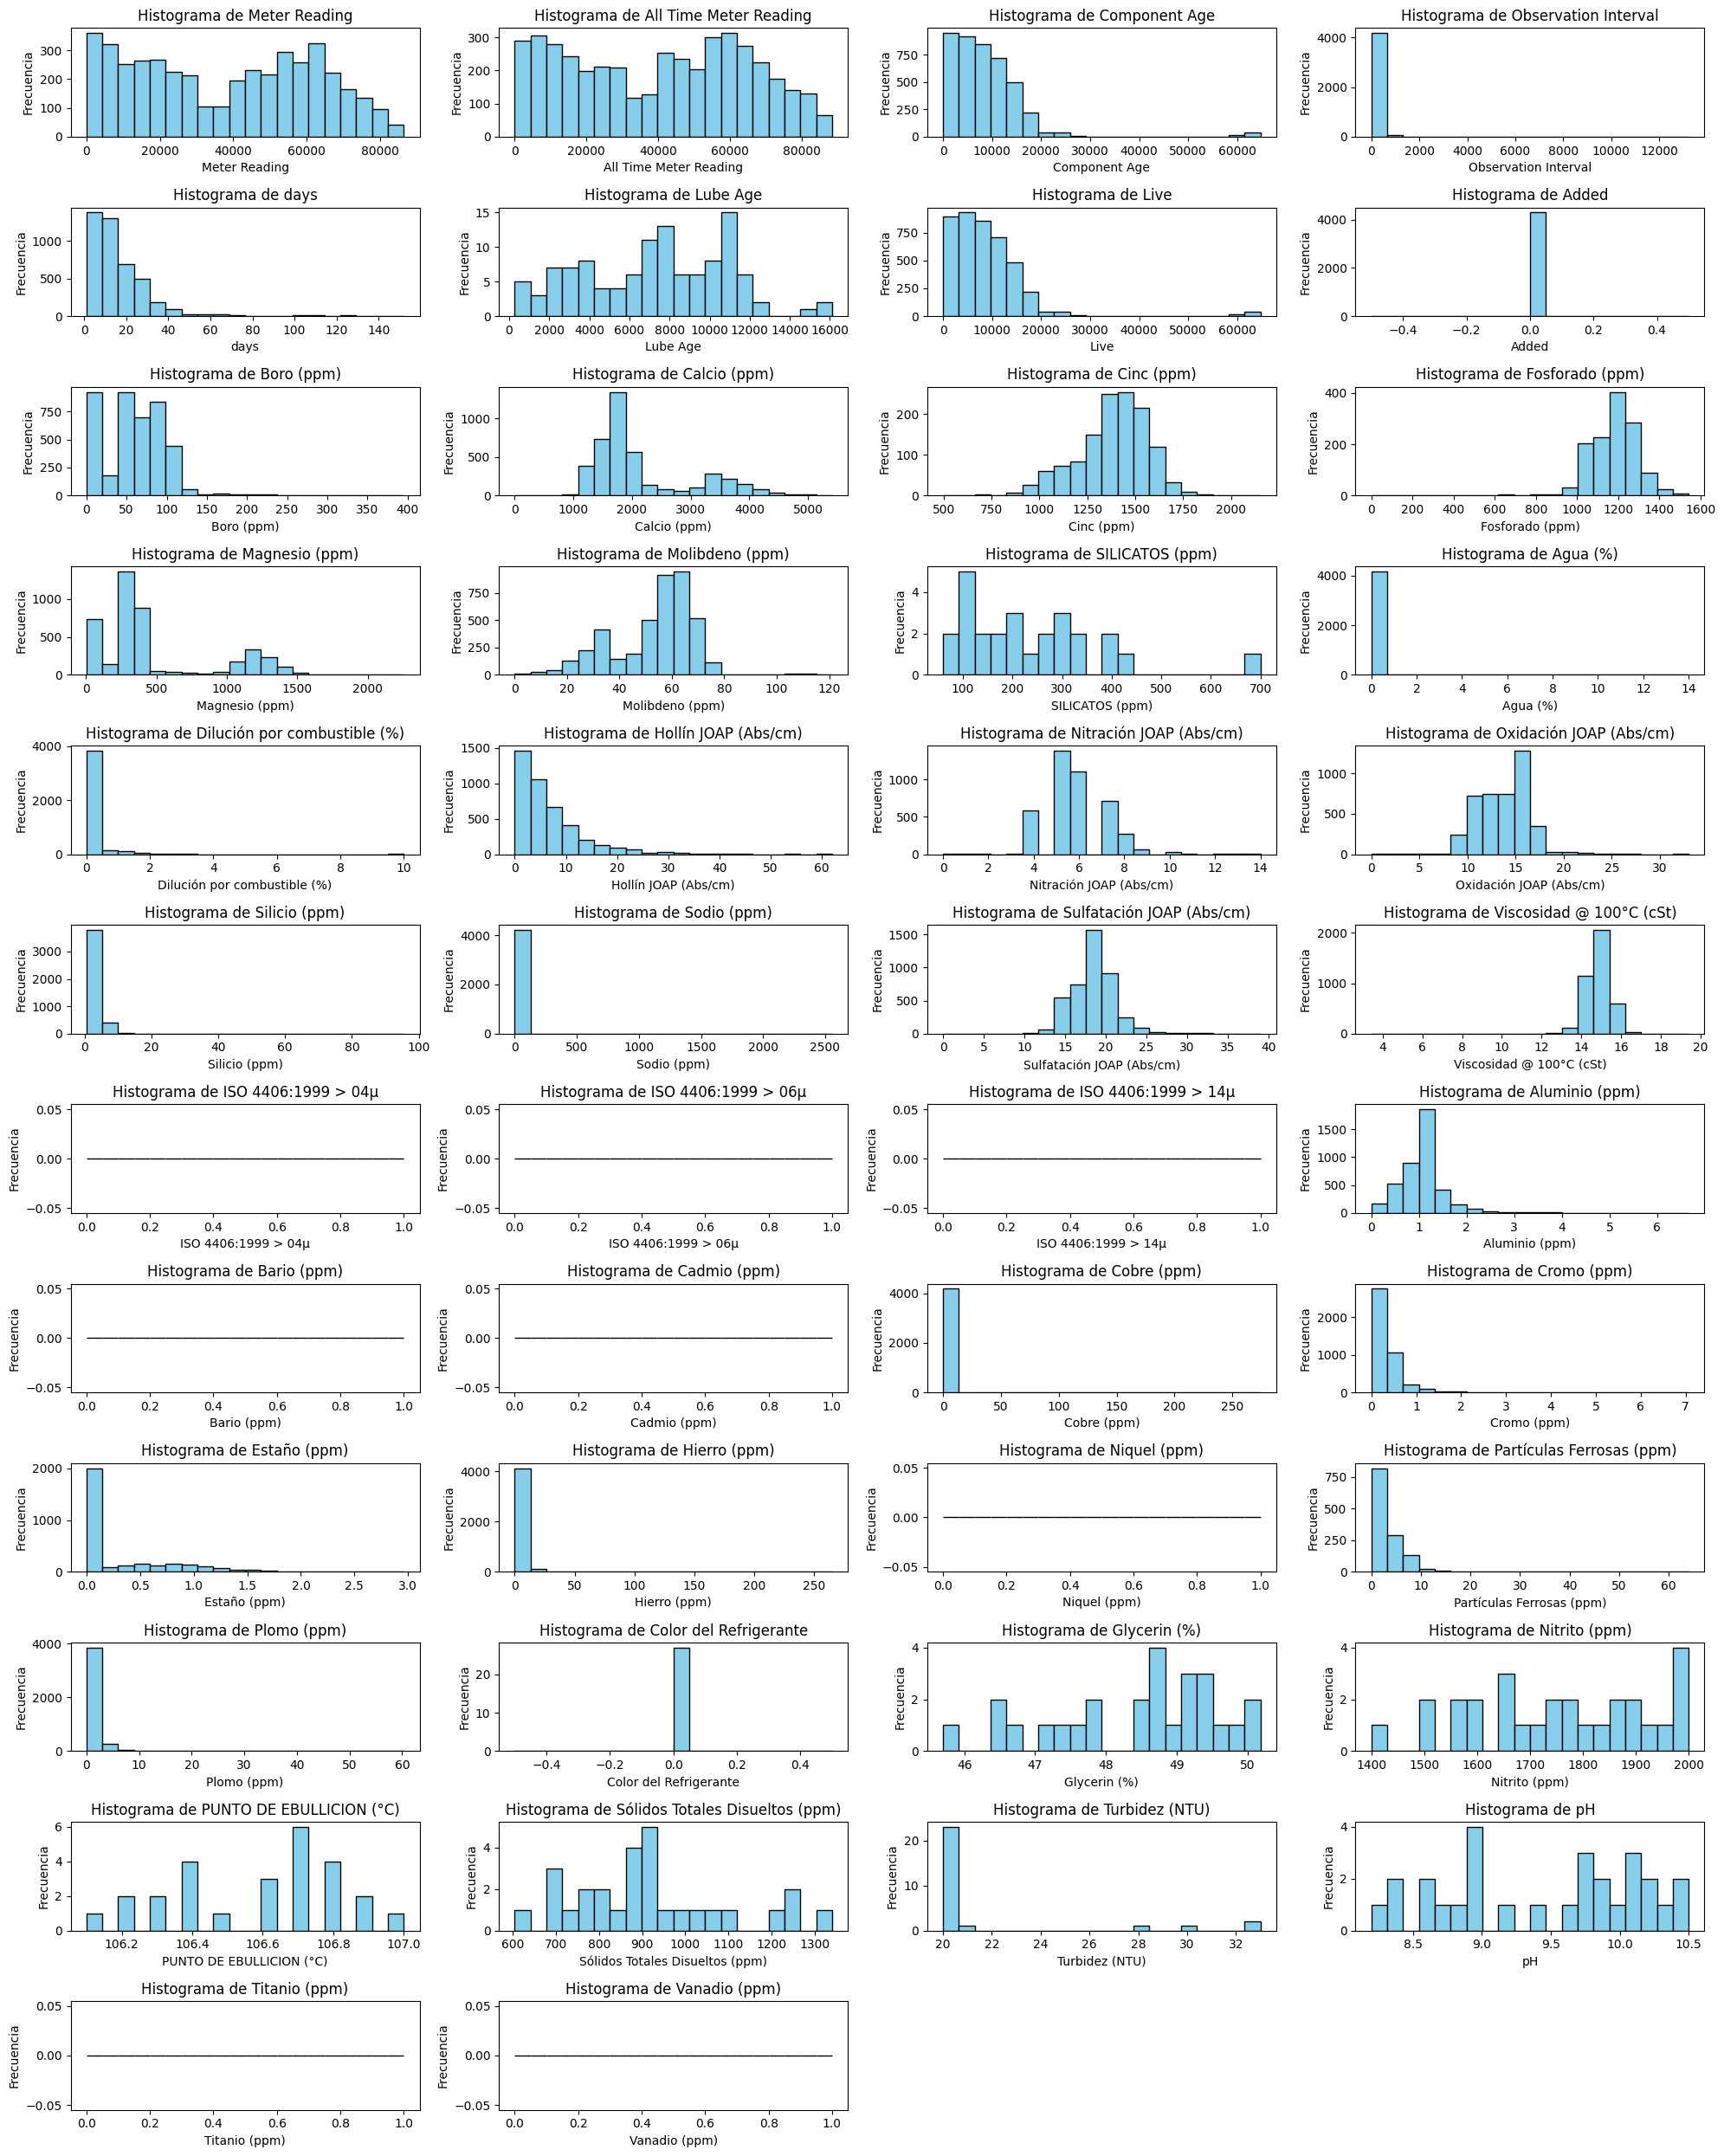

In [42]:
numerical_columns = data.select_dtypes(include=['int64',"float64"]).columns

# Determinar el tamaño de la cuadrícula
n_cols = 4
n_rows = (len(numerical_columns) + n_cols - 1) // n_cols  # Redondeo hacia arriba para que haya suficiente espacio

# Crear la figura y los ejes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 25))
axes = axes.flatten()  # Aplanar los ejes para iterar sobre ellos fácilmente

# Generar un histograma para cada columna numérica
for i, col in enumerate(numerical_columns):
    axes[i].hist(data[col].dropna(), bins=20, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Histograma de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

# Eliminar cualquier gráfico extra (en caso de que haya más subplots que columnas)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Ajustar el espaciado entre gráficos
plt.tight_layout()
plt.show()

* La mayoría de las variables están fuertemente sesgadas a la derecha.
  * La mayoría de las variables muestran distribuciones fuertemente sesgadas a la derecha.
  * Hay colas largas y presencia evidente de outliers extremos en múltiples variables (metales, JOAP, sólidos disueltos, sodio, silicio, etc.).
  * Esto sugiere procesos con valores excepcionales pero poco frecuentes, típicos de análisis de aceite contaminado o en falla.
* Outliers extremos: hay valores aislados muy altos en varios contaminantes y lecturas temporales; se debe verificar si representan fallas reales o errores de medición.
* Variables con valores casi nulos o detección limitada: varios metales (Bario, Cadmio, Níquel, Vanadio, Titanio, etc.) concentran la mayoría de observaciones en 0-cercano a 0 con pocos valores detectables → posible límite de detección del instrumento
* Histogramas planos o vacíos indican alta falta de datos o constantes: ISO 4406 y algunas trazas muestran prácticamente ninguna variación, esto debido a que se trata de datos faltantes en su mayoria.
* Las variables relacionadas con tiempo o uso del equipo tienen gran dispersión.

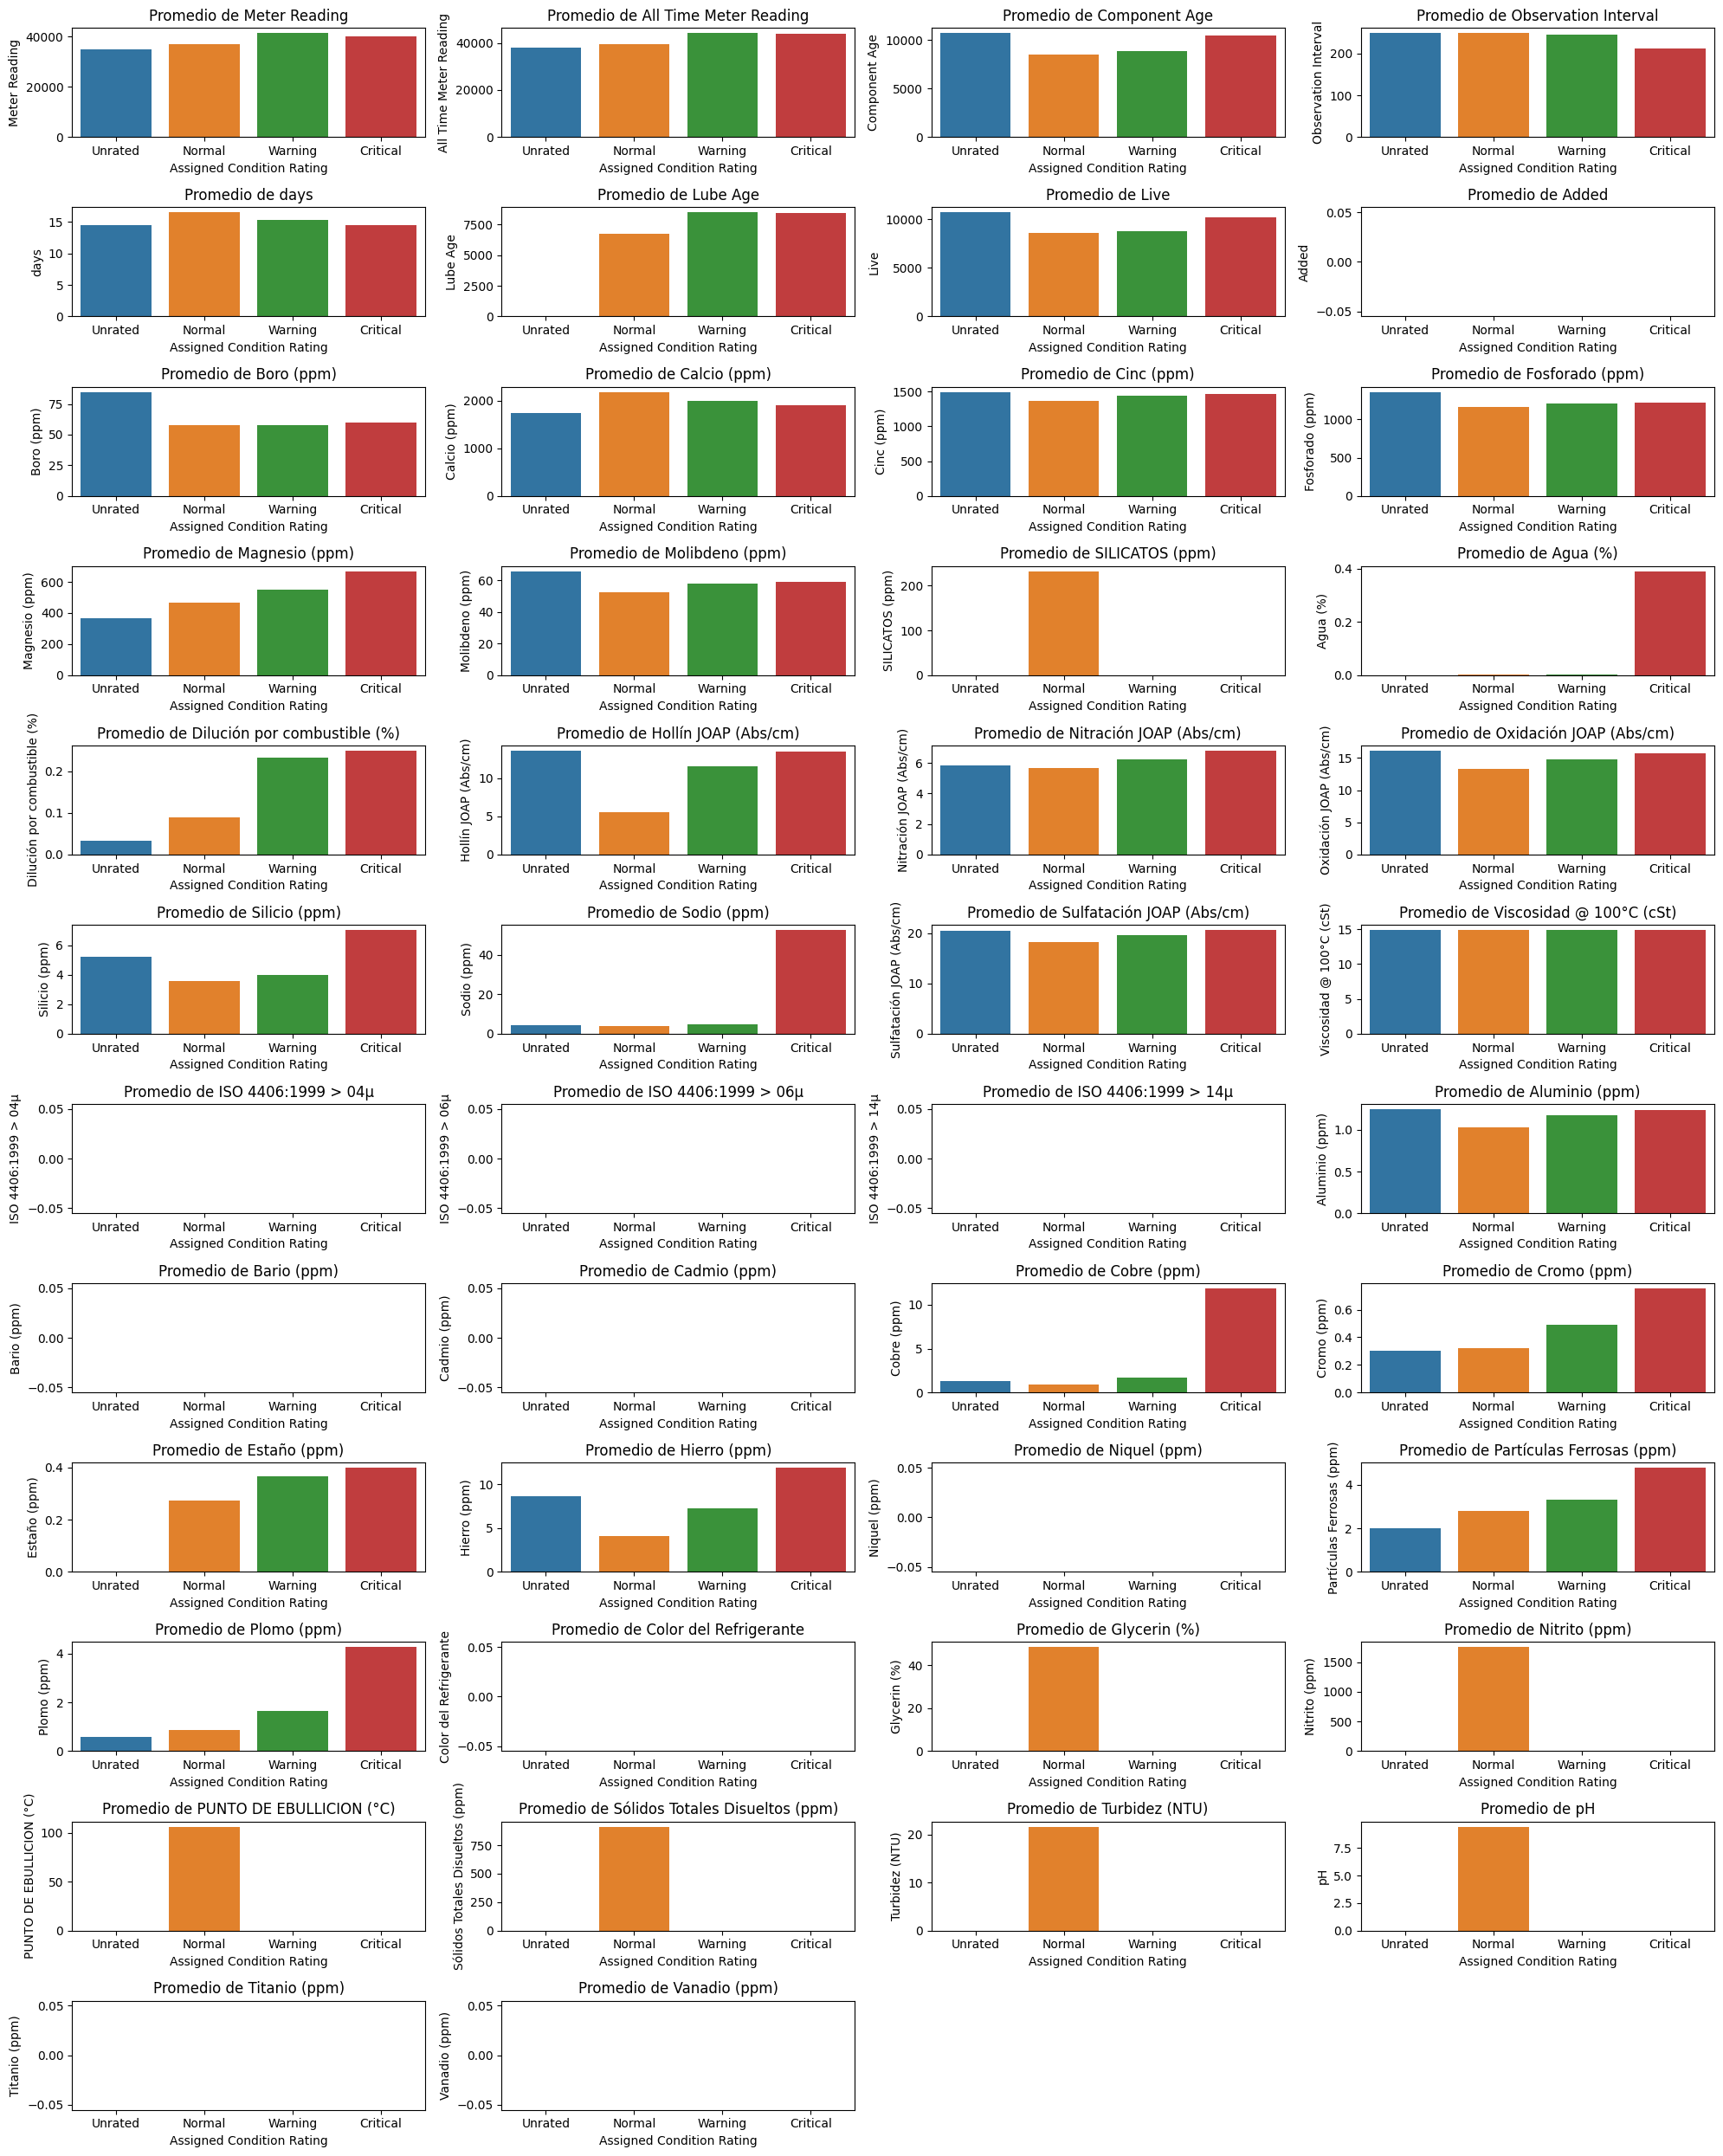

In [39]:
import seaborn as sns
plt.figure(figsize=(20, 25))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(12, 4, i)  
    sns.barplot(x='Assigned Condition Rating', y=col, data=data, errorbar=None, hue='Assigned Condition Rating')
    plt.title(f'Promedio de {col}')
    plt.xlabel('Assigned Condition Rating')
    plt.ylabel(col)
    plt.xticks(rotation=0)

plt.tight_layout()  
plt.show()

* Incremento progresivo hacia “Critical”: En la mayoría de los parámetros (metales, JOAP, sólidos, viscosidad, partículas), los valores promedio aumentan al pasar de Normal → Warning → Critical, validando la coherencia del sistema de clasificación. Esta variables terminan siendo fuertes candidatos a ser indicadores tempranos de desgaste o contaminación.
* JOAP (Hollín, Oxidación, Nitración, Sulfatación): Exhiben el patrón más consistente y marcado: valores significativamente más altos en Warning y, sobre todo, Critical. Son variables clave para modelar condición del aceite.
* Algunos metales con valores muy bajos: Muchos permanecen en cero o valores muy bajos en todas las categorías, lo cual limita su valor discriminante para estratificación de condición.


## Parte III: Técnicas de limpieza

* Rango de los datos y validez
* Faltantes y coherencia de los tipos de datos
* Outliers y justificar si se deben o no eliminar o imputar
* Correlaciones entre las variables

Ante los hallazgos de esta etapa se deben plantear alternativas de tratamiento (Eliminación o imputación)

In [10]:
# Se eliminan Variabes no necesarias
data = data.dropna(axis=1, how='all')
data = data.drop(
	columns=[
		'Color del Refrigerante','Glycerin (%)','Nitrito (ppm)','PUNTO DE EBULLICION (°C)',
		'Sólidos Totales Disueltos (ppm)','Turbidez (NTU)','pH','Added','Lube Drained','Live',
		'Lube Age','days','Observation Interval','Component Age', 'All Time Meter Reading',
		'Meter Reading','Observation Code','Observation Date', 'Observation Type','Connection Code',
		'Lubricant','Component Profile','Location','Component ID','SILICATOS (ppm)','Asset ID'
	],
	errors='ignore'
)

In [4]:
# Se agrupan las varibles segun la metodologia SACODE 

Salud = data[['Boro (ppm)', 'Calcio (ppm)', 'Cinc (ppm)', 'Fosforado (ppm)', 'Magnesio (ppm)', 'Molibdeno (ppm)', 'Nitración JOAP (Abs/cm)', 'Oxidación JOAP (Abs/cm)', 'Sulfatación JOAP (Abs/cm)','Sodio (ppm)']]
Desgaste = data[['Aluminio (ppm)', 'Cobre (ppm)', 'Cromo (ppm)', 'Estaño (ppm)', 'Hierro (ppm)', 'Partículas Ferrosas (ppm)', 'Plomo (ppm)','Oxidación JOAP (Abs/cm)' ]]
Contaminacion = data[['Agua (%)', 'Dilución por combustible (%)', 'Hollín JOAP (Abs/cm)', 'Silicio (ppm)','Sodio (ppm)','Aluminio (ppm)']]

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("\n=== Tipos de datos iniciales ===")
print(data.dtypes)

print("\n=== Rango (mínimo y máximo) de variables numéricas ===")
rangos = data.select_dtypes(include=[np.number]).agg(['min','max']).T
print(rangos)

print("\n=== Porcentaje de faltantes por columna ===")
faltantes = data.isna().mean().sort_values(ascending=False)*100
print(faltantes)

posibles_numericas = []
for col in data.columns:
    if data[col].dtype == 'object':
        try:
            pd.to_numeric(data[col].astype(str).str.replace(',','.'), errors='raise')
            posibles_numericas.append(col)
        except:
            pass

print("\n=== Posibles columnas numéricas mal tipificadas como object ===")
print(posibles_numericas)


print("\n=== Detección de Outliers  ===")

def detectar_outliers(col):
    q1 = col.quantile(0.25)
    q3 = col.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    return ((col < lower) | (col > upper)).sum()

outliers_resumen = {}
for col in data.select_dtypes(include=[np.number]).columns:
    outliers_resumen[col] = detectar_outliers(data[col])

outliers_df = pd.DataFrame.from_dict(outliers_resumen, orient='index', columns=['Outliers'])
print(outliers_df.sort_values('Outliers', ascending=False))

# === Boxplots automáticos por columna (para inspección visual) ===
for col in data.select_dtypes(include=[np.number]).columns:
    # Skip columns with all NaN or no valid data
    if data[col].dropna().empty:
        continue



numericas = data.select_dtypes(include=[np.number])

print("\n=== Matriz de correlaciones ===")
corr = numericas.corr()
print(corr)







=== Tipos de datos iniciales ===
Flota                                   object
Observation Rating                      object
Trakka Rating                           object
Assigned Condition Rating               object
Condition Review Notes                  object
Further Recommendations                 object
Fault Effect                            object
Reviewed                        datetime64[ns]
Reviewer                                object
Action Summary                          object
Boro (ppm)                             float64
Calcio (ppm)                           float64
Cinc (ppm)                             float64
Fosforado (ppm)                        float64
Magnesio (ppm)                         float64
Molibdeno (ppm)                        float64
Agua (%)                               float64
Dilución por combustible (%)           float64
Hollín JOAP (Abs/cm)                   float64
Nitración JOAP (Abs/cm)                float64
Oxidación JOAP (Abs/cm)   

<Axes: >

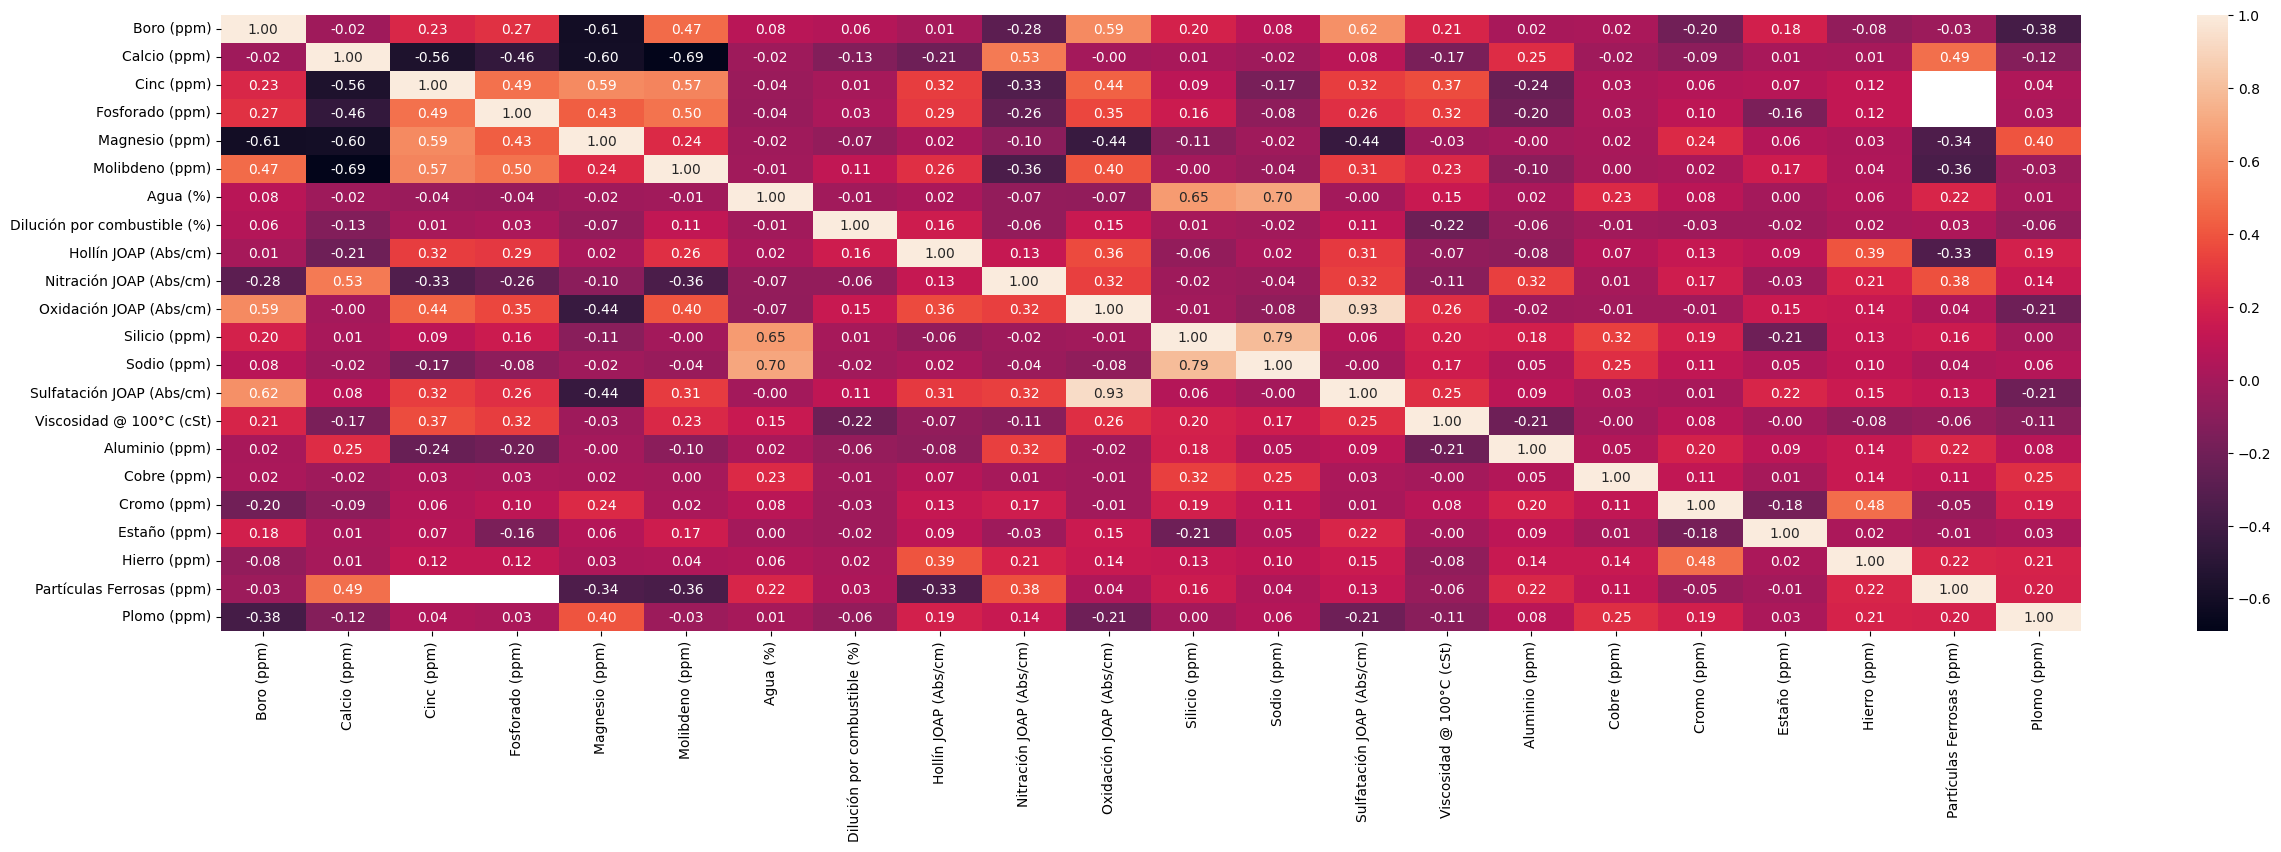

In [11]:
corr = data.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(30,8))
sns.heatmap(corr, annot=True, fmt=".2f")